#EN:Importing Required Libraries — Importing essential libraries for data manipulation, visualization, and machine learning models.

#TR:Gerekli Kütüphanelerin Yüklenmesi — Veri işleme, görselleştirme ve makine öğrenmesi modelleri için temel kütüphanelerin içeri aktarılması.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import time

In [3]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score

#EN:Loading the Dataset — Loading the UCI HAR train and test datasets into pandas DataFrames.

#TR:Veri Setinin Yüklenmesi — UCI HAR eğitim ve test veri setlerinin pandas DataFrame yapısına aktarılması.

In [4]:
trainData = pd.read_csv("train.csv")
testData = pd.read_csv("test.csv")

In [5]:
trainData.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


#EN:Exploratory Data Analysis (Class Distribution) — Visualizing the frequency distribution of the 6 human activities to evaluate class balance.

#TR:Keşifçi Veri Analizi (Sınıf Dağılımı) — Sınıf dengesini incelemek amacıyla 6 farklı insan aktivitesinin dağılım grafiğinin çizdirilmesi.   

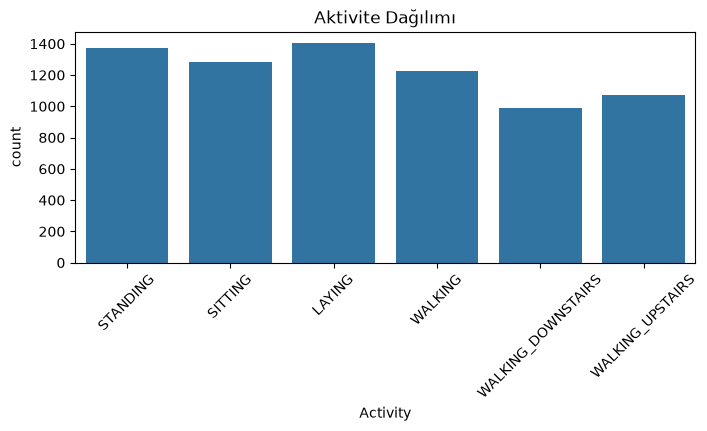

In [6]:
plt.figure(figsize=(8,3))
sns.countplot(x="Activity",data=trainData)
plt.xticks(rotation=45)
plt.title("Aktivite Dağılımı")
plt.show()           

#EN:Data Preprocessing and Feature Scaling — Encoding categorical class labels with LabelEncoder and standardizing features via StandardScaler.

#TR:Veri Ön İşleme ve Ölçeklendirme — Kategorik sınıf etiketlerinin LabelEncoder ile dönüştürülmesi ve özniteliklerin StandardScaler ile ölçeklendirilmesi.   

In [7]:
from sklearn.preprocessing import LabelEncoder

In [8]:
kodlama = LabelEncoder()

In [9]:
sozel_sutunlar = trainData.select_dtypes(include=['object']).columns
print( sozel_sutunlar)

Index(['Activity'], dtype='str')


In [10]:
trainData["Activity"] = kodlama.fit_transform(trainData["Activity"])
testData["Activity"] = kodlama.transform(testData["Activity"])

In [11]:
X_train = trainData.drop(['subject', 'Activity'], axis=1)
y_train = trainData['Activity']

X_test = testData.drop(['subject', 'Activity'], axis=1)
y_test = testData['Activity']

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#EN:Model Training and Benchmarking — Training 9 machine learning algorithms and evaluating their accuracy scores and computation runtimes.

#TR:Model Eğitimi ve Karşılaştırmalı Değerlendirme — 9 farklı makine öğrenmesi algoritmasının eğitilmesi, doğruluk oranları ve çalışma sürelerinin karşılaştırılması.

In [13]:
# 9 Farklı Klasik Makine Öğrenmesi Algoritması
modeller = {
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Lojistik Regresyon": LogisticRegression(max_iter=1000),
    "Karar Ağacı": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, max_depth=3),
    "AdaBoost": AdaBoostClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1) # Literatürden eklendi
}

sonuclar = []


for isim, model in modeller.items():
    baslangic = time.time()
    
    # Modeli eğitme
    model.fit(X_train_scaled, y_train)
    egitim_suresi = time.time() - baslangic
    
    # Tahmin yapma ve başarıyı ölçme
    tahmin = model.predict(X_test_scaled)
    basari = accuracy_score(y_test, tahmin)
    
    sonuclar.append({
        "Model": isim,
        "Doğruluk (Accuracy)": basari,
        "Eğitim Süresi (sn)": egitim_suresi
    })

# Sonuçları karşılaştırmalı tablo olarak gösterme
df_karsilastirma = pd.DataFrame(sonuclar).sort_values(by="Doğruluk (Accuracy)", ascending=False)
print(df_karsilastirma)

                Model  Doğruluk (Accuracy)  Eğitim Süresi (sn)
3  Lojistik Regresyon             0.954530            1.991219
0                 SVM             0.951815            1.904149
7         Extra Trees             0.940618            2.052482
5   Gradient Boosting             0.931456          257.366965
1       Random Forest             0.927723            7.718015
8                 QDA             0.924330            1.002760
2                 KNN             0.883610            0.019276
4         Karar Ağacı             0.861554            3.198214
6            AdaBoost             0.349169           18.814584


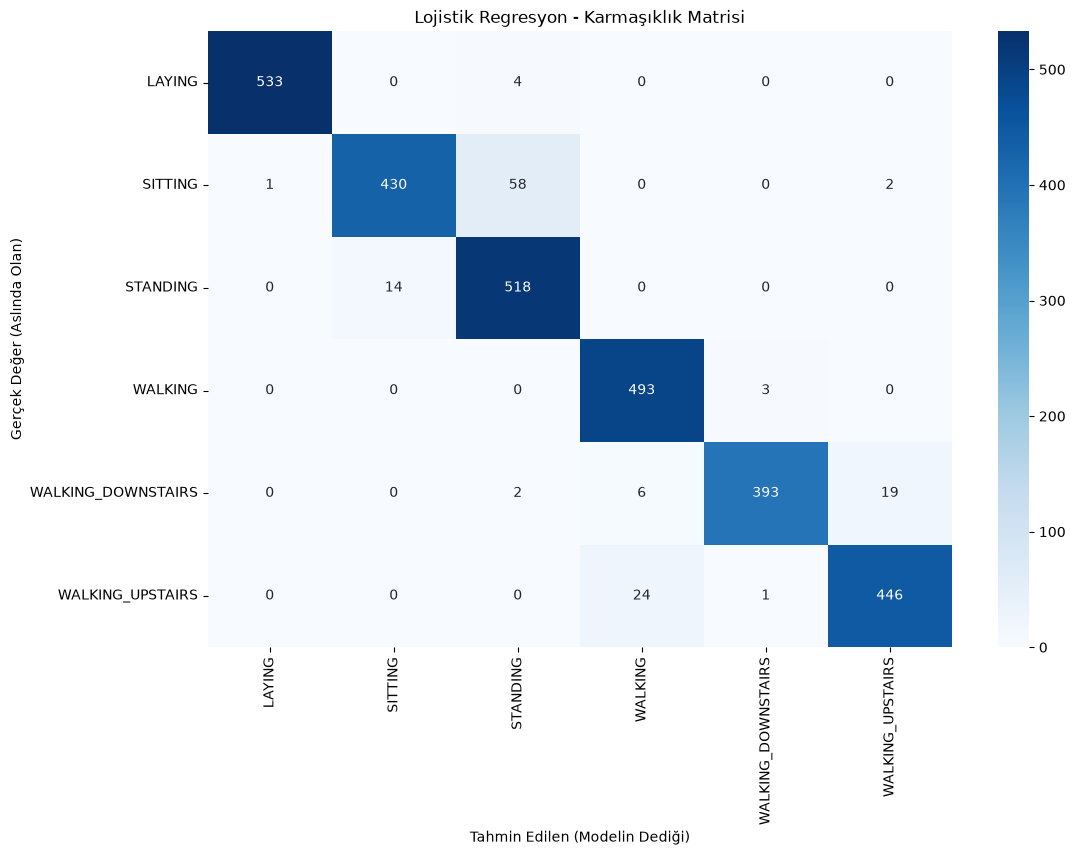

In [14]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


y_pred = modeller["Lojistik Regresyon"].predict(X_test_scaled)


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=kodlama.classes_, 
            yticklabels=kodlama.classes_, 
            cmap='Blues')
plt.xlabel('Tahmin Edilen (Modelin Dediği)')
plt.ylabel('Gerçek Değer (Aslında Olan)')
plt.title('Lojistik Regresyon - Karmaşıklık Matrisi')
plt.show()

In [15]:
from sklearn.metrics import precision_recall_fscore_support

metrik_sonuclari = []

for isim, model in modeller.items():
    y_pred = model.predict(X_test_scaled)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    metrik_sonuclari.append({
        "Model": isim,
        "Doğruluk (Accuracy)": accuracy_score(y_test, y_pred),
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

df_metrikler = pd.DataFrame(metrik_sonuclari).sort_values(by="F1-Score", ascending=False)
print(df_metrikler.to_string(index=False))

             Model  Doğruluk (Accuracy)  Precision   Recall  F1-Score
Lojistik Regresyon             0.954530   0.956277 0.954530  0.954449
               SVM             0.951815   0.952236 0.951815  0.951711
       Extra Trees             0.940618   0.942331 0.940618  0.940209
 Gradient Boosting             0.931456   0.932736 0.931456  0.931190
     Random Forest             0.927723   0.928995 0.927723  0.927521
               QDA             0.924330   0.931710 0.924330  0.923213
               KNN             0.883610   0.890576 0.883610  0.882687
       Karar Ağacı             0.861554   0.861871 0.861554  0.861172
          AdaBoost             0.349169   0.154783 0.349169  0.212841


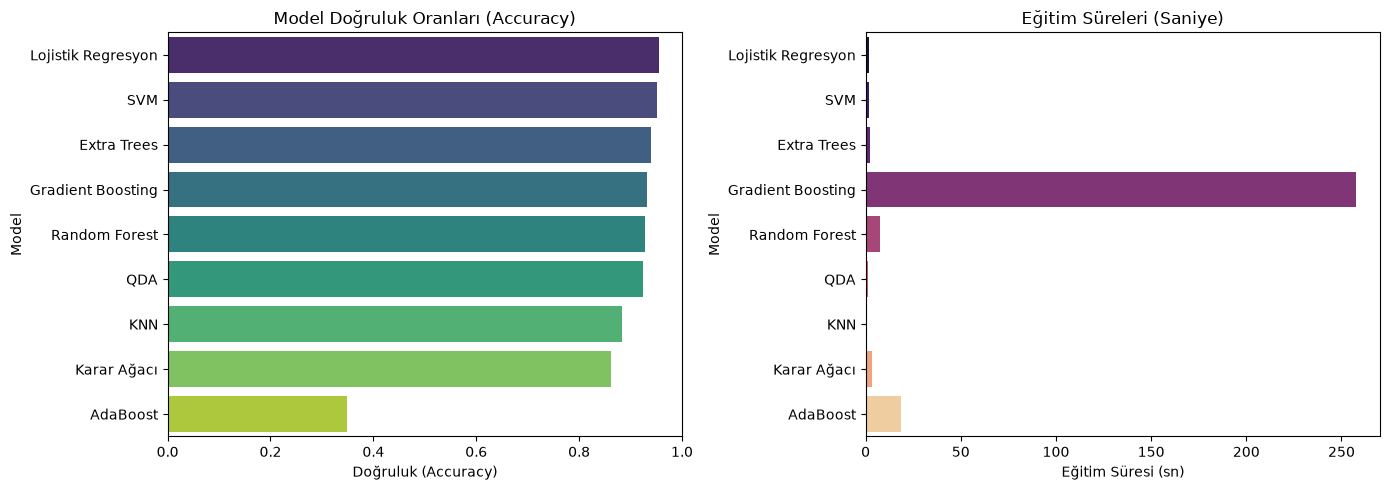

In [16]:
plt.figure(figsize=(14, 5))

# Başarım Grafiği
plt.subplot(1, 2, 1)
sns.barplot(x="Doğruluk (Accuracy)", y="Model", data=df_karsilastirma, palette="viridis")
plt.title("Model Doğruluk Oranları (Accuracy)")
plt.xlim(0, 1.0)

# Eğitim Süresi Grafiği
plt.subplot(1, 2, 2)
sns.barplot(x="Eğitim Süresi (sn)", y="Model", data=df_karsilastirma, palette="magma")
plt.title("Eğitim Süreleri (Saniye)")

plt.tight_layout()
plt.show()

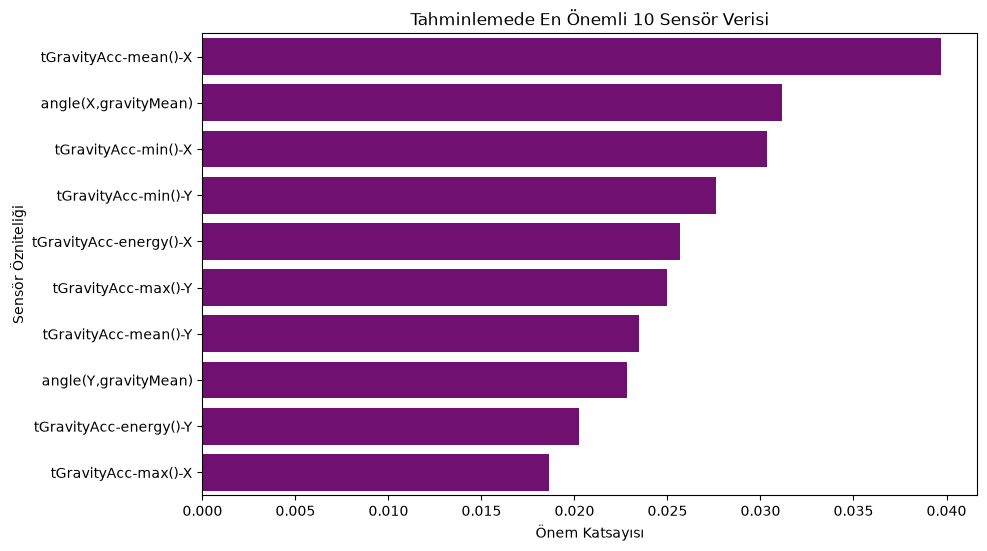

In [17]:
rf_model = modeller["Random Forest"]
ozellik_adlari = X_train.columns
onem_dereceleri = rf_model.feature_importances_

df_onem = pd.DataFrame({
    'Sensör Özniteliği': ozellik_adlari,
    'Önem Derecesi': onem_dereceleri
}).sort_values(by='Önem Derecesi', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Önem Derecesi', y='Sensör Özniteliği', data=df_onem, color='purple')
plt.title('Tahminlemede En Önemli 10 Sensör Verisi')
plt.xlabel('Önem Katsayısı')
plt.show()

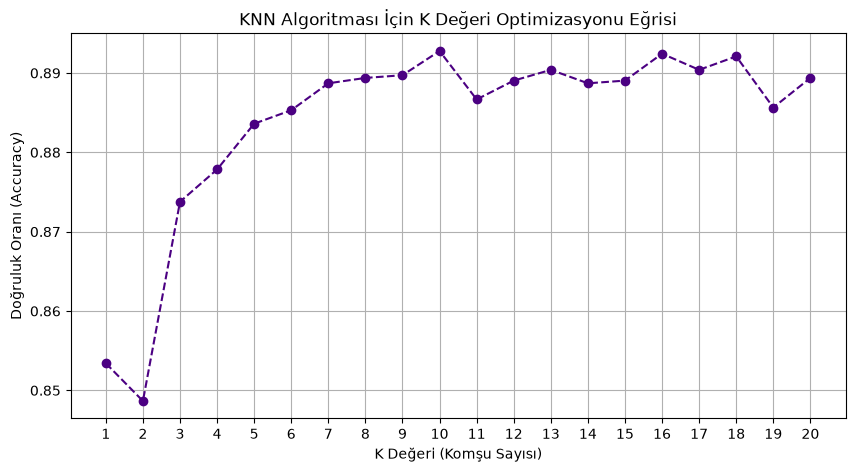

In [18]:
k_degerleri = list(range(1, 21))
k_skorlari = []

for k in k_degerleri:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    k_skorlari.append(knn.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 5))
plt.plot(k_degerleri, k_skorlari, marker='o', linestyle='dashed', color='indigo')
plt.title('KNN Algoritması İçin K Değeri Optimizasyonu Eğrisi')
plt.xlabel('K Değeri (Komşu Sayısı)')
plt.ylabel('Doğruluk Oranı (Accuracy)')
plt.xticks(k_degerleri)
plt.grid(True)
plt.show()

---
### 👨‍💻 Hazırlayan / Author Information

* **Name / İsim:** Yusuf Kaan Saçlı
* **Education / Eğitim:**
  * **Master's Degree (Ongoing) / Yüksek Lisans (Devam Ediyor):** Artificial Intelligence and Data Science, Sivas Cumhuriyet University / Sivas Cumhuriyet Üniversitesi, Yapay Zeka ve Veri Bilimi Tezli Yüksek Lisans
  * **Bachelor's Degree / Lisans:** Statistics & Computer Science, Sivas Cumhuriyet University (2026) / Sivas Cumhuriyet Üniversitesi, İstatistik ve Bilgisayar Bilimleri (2026)
* **Thesis Topic / Tez Konusu:** Human Activity Recognition (HAR) Using Smartphone Sensor Data & Machine Learning / Akıllı Telefon Sensör Verileri Kullanılarak Makine Öğrenmesi ile İnsan Aktivitelerinin Sınıflandırılması
* **GitHub Profile / GitHub Profili:** https://github.com/YKaanSacli
* **LinkedIn Profile / LinkedIn Profili:** https://www.linkedin.com/in/yusufkaansacli